In [1]:
import collections
import matplotlib.pyplot as plt
from IPython import display
import itertools as itr
import numpy as np
import math
from sklearn.metrics import mean_squared_error
from random import randrange
import json

import torch
from torch import Tensor, nn
from torch import optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.func import functional_call, vmap, vjp, jvp, grad

from scipy.linalg import svdvals, norm
from scipy.special import softmax
from scipy.optimize import minimize_scalar

from common.const import DATASET_PATH
from common.util import *
from common.ffn_model.minst.ffn_minst_util import MetaData
from common.ffn_model.minst.ffn_minst_optimise import reduce_to_active, ntkvp2_np, NTK_softmaxV3, solve_eta_norm2
from common.ffn_model.minst.ffn_minst_relu import ParametricReLUNet

from torchvision.datasets import CIFAR10
from torchvision import transforms

import logging

In [2]:
logging.basicConfig(filename="log_convcrity_cifar10_epoch1d-prelib.log",
                level=logging.INFO,
                format="%(levelname)s: %(asctime)s %(message)s")
                #datefmt="%Y-%m-%d %H:%M:%S,%(msecs)")
                #datefmt="%d/%m/%Y %I:%M:%S")


#### CIRAR10 dataset

In [3]:
# Convert from PIL to torch.Tensort
# and normalize each pixel from [0, 255] range to [0.0, 1.0]
base_transforms = transforms.ToTensor()

# An augmentation that randomly (with a probability equal to 0.5)
# flips the image horizontally
# This will prevent overfitting and make the model more robust
aug_transforms = transforms.RandomHorizontalFlip(p=0.5)

# Gather all transforms together
train_transforms = transforms.Compose([
    base_transforms,
    aug_transforms
])

train_dataset = CIFAR10(root=DATASET_PATH, train=True, download=True, transform=train_transforms)

# Note that we only use `base_transforms` for test dataset
test_dataset = CIFAR10(root=DATASET_PATH, train=False, download=True, transform=base_transforms)

Files already downloaded and verified
Files already downloaded and verified


In [4]:
BATCH_SIZE = 32
NUM_EPOCH = 1

# `pin_memory` speed up processing if you use GPU
# `num_workers` also speed up processing since use additional process
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=0, pin_memory=True)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                             num_workers=0, pin_memory=True)

##### UTILS

In [5]:

def visualise(history_params):
    # visualize all together
    display.clear_output()
    fig, axes = plt.subplots(2, 2, figsize=(20, 14))
    axes[0, 0].set_title('Loss (cross-entropy)')
    axes[0, 0].plot(history_params['train_loss'], label='Train Loss')
    axes[0, 0].plot(history_params['test_loss'], label='Test Loss')
    axes[0, 0].grid()
    axes[0, 0].legend(fontsize=20)
    
    axes[0, 1].set_title('Accuracy')
    axes[0, 1].plot(history_params['train_accuracy'], label='Train Accuracy')
    axes[0, 1].plot(history_params['test_accuracy'], label='Test Accuracy')
    axes[0, 1].grid()
    axes[0, 1].legend(fontsize=20)

    axes[1, 0].set_title('Train-step eta')
    axes[1, 0].plot(history_params['train_eta'])
    axes[1, 0].grid()
    #ax2.legend(fontsize=20)

    '''
    axes[1, 1].set_title('Singular values for flattened NTK')
    #axes[1, 1].plot(history_params['ntk_sungular_min'], label='Singular min value')
    axes[1, 1].plot(history_params['train_ntk_sungular_max'], label='Singular max value')
    axes[1, 1].grid()
    axes[1, 1].legend(fontsize=20)
    '''
    
    plt.show()


#### Metadata:

In [6]:
#Weights distribution variances are set as in (5.67)
slope_plus, slope_minus=1.0, 0.1
cb, cw = 0, 2.0/(slope_plus**2.0 + slope_minus**2.0)

'''
INPUT_DIM=32*32*3
OUTPUT_DIM = 10

INPUT_WIDTH, HIDDEN_WIDTH = 4096, 512

lb, lw = 0.005, 5.0
'''
class MetaData:
    def __init__(self, batch_size, output_dim):
        self.batch_size = batch_size
        self.output_dim = output_dim  # num of classes

OUTPUT_DIM = 10
meta = MetaData(output_dim = OUTPUT_DIM, batch_size = BATCH_SIZE)

DEVICE = torch.device('cpu')  # change to `cuda:0` when available

#### CNN with norm2-optimiser, λμν=I

In [7]:
class CIFAR10ReLU(nn.Module):
    def __init__(self):
        super().__init__()
        self.slope_positive = None
        self.slope_negative = None
        self.do_dropout = False

        self.kernel_size_=(3, 3)
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=self.kernel_size_, padding='same')
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=self.kernel_size_, padding='same')
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=self.kernel_size_, padding='same')
        self.conv4 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=self.kernel_size_, padding='same')
        self.linear5 = nn.Linear(4096, 256)
        self.linear6 = nn.Linear(256, 10)

    def set_slopes(self, slope_positive = 1.0, slope_negative = 0.25):
        self.slope_positive = slope_positive
        self.slope_negative = slope_negative

    def PReLU(self, input: Tensor) -> Tensor:
        input = torch.where(input >= 0, self.slope_positive * input, self.slope_negative * input)
        return input

    def forward_(self, x):
        return self.forward(x)
    
    def forward(self, x):
        #channels*size*size
        #3*32*32->16*32*32 <padding='same'?>
        h1 = self.PReLU(self.conv1(x))
        #16*32*32->32*32*32->32*16*16 <padding='same'?>
        h2 = F.max_pool2d(self.PReLU(self.conv2(h1)), 2)
        if self.do_dropout:
            h2 = F.dropout(h2, 0.25)
        #32*16*16->32*16*16 <padding='same'?>
        h3 = self.PReLU(self.conv3(h2))
        #32*16*16->64*16*16->64*8*8 <padding='same'?>
        h4 = F.max_pool2d(self.PReLU(self.conv4(h3)), 2)
        if self.do_dropout:
            h4 = F.dropout(h4, 0.25)
        #64*8*8->4096->256
        h4flat = torch.flatten(h4, 1)
        h5 = self.PReLU(self.linear5(h4flat))
        if self.do_dropout:
            h5 = F.dropout(h5, 0.5)
        return self.linear6(h5)
    
    def init_weights(self, cb=0.0, cw=1.0):
        logging.debug("CNN weights initialisation with cb={}, cw={}".format(cb, cw))

        #Weight initialisation as in 2.19, 2.20
        self.cb, self.cw = cb, cw
        kernel_size = self.kernel_size_[0]*self.kernel_size_[1]
        self.init_linear_weights(self.conv1, True, cb, cw/kernel_size)
        self.init_linear_weights(self.conv2, True, cb, cw/kernel_size)
        self.init_linear_weights(self.conv3, True, cb, cw/kernel_size)
        self.init_linear_weights(self.conv4, True, cb, cw/kernel_size)
        self.init_linear_weights(self.linear5, True, cb, cw/self.linear5.in_features)
        self.init_linear_weights(self.linear6, True, cb, cw/self.linear6.in_features)

    @staticmethod
    def init_linear_weights(linear, bias_on, var_b=0.0, var_w=1.0):
        nn.init.normal_(linear.weight, mean = 0., std = math.sqrt(var_w)) #approach via torch
        if bias_on:
            nn.init.normal_(linear.bias, mean = 0., std = math.sqrt(var_b))

    @staticmethod
    def init_linear_zeros(linear, bias_on):
        nn.init.zeros_(linear.weight)
        if bias_on:
            nn.init.zeros_(linear.bias)

In [8]:
class ParameterProcessor:
    def __init__(self):
        self.theta_current = {}
        self.delta_current = {}
        self.grad_current = {}

    def is_delta_empty(self):
        return len(self.delta_current) <= 0

    def save_theta(self, model):
        with torch.no_grad():        
            for name, param in model.named_parameters():
                self.theta_current[name] = param.detach().clone()

    def set_theta(self, model, momentum, eta, eta_scale = 1.0):
        with torch.no_grad():
            for name, param in model.named_parameters():
                grad = self.grad_current[name]
                delta = self.delta_current.get(name, None)
                if momentum <= 0.0 and eta_scale > 0.0:
                    param.data.copy_(self.theta_current[name] -eta * eta_scale * grad)
                elif eta_scale <= 0.0 and momentum > 0.0:
                    if delta is not None:
                        param.data.copy_(self.theta_current[name] + momentum * delta)
                    else:
                        param.data.copy_(self.theta_current[name])
                elif eta_scale > 0.0 and momentum > 0.0:
                    if delta is not None:
                        param.data.copy_(self.theta_current[name] + momentum * delta - eta * eta_scale * grad)
                    else:
                        param.data.copy_(self.theta_current[name] - eta * eta_scale * grad)
                else:
                    raise ValueError("eta_scale or momentum must be in interval(0., 1.)")

    def save_delta_current(self, momentum, eta, eta_scale = 1.0):
        for name, grad in self.grad_current.items():
            delta = self.delta_current.get(name, None)
            if delta is None or momentum <= 0.0:
                self.delta_current[name] = -eta * eta_scale * grad
            else:
                self.delta_current[name] = momentum * delta - eta * eta_scale * grad

    #Grad optionally multiplied by lambda
    def calc_autograd(self, model, loss, lambda_dict=None):
        param_buffer ={}
        for name, param in model.named_parameters():
            param_buffer[name] = param        
        df = torch.autograd.grad(loss, param_buffer.values()) #, retain_graph=True, create_graph=True, allow_unused=True)
        ii = 0
        for name in param_buffer:
            lambda_value = lambda_dict.get(name, 1.) if lambda_dict is not None else 1.
            self.grad_current[name] = lambda_value * df[ii].detach().clone()
            ii += 1
    
class OptimiserEtaSoftmaxArmihoNorm2Base:
    def __init__(self, meta, momentum=0.9, lbd_dict=None):
        self.meta = meta
        self.momentum = momentum
        self.step_one = 1.0
        #self.step_deltas = [0.0]
        self.step_deltas = [0.0, -0.5, -0.25, -0.125, -0.0625, -0.03125, -0.015625, -0.015625]
        #self.step_deltas = [3.0, -2.0, -1.0, -0.5, -0.25, -0.125, -0.0625, -0.03125, -0.015625]
        #self.step_deltas = [1.0, -1.0, -0.5, -0.25, -0.125, -0.0625, -0.03125, -0.015625]
        self.c1 = 0.0 #0.000000005 #0.000005 #0.000025
        self.c2 = 0.99 #0.75 #0.5#
        self.c3 = 0.99

        self.epsilon = 1e-8
        self.epsilon_criteria = 1e-5
        self.eta_min = self.epsilon
        self.lbd_dict = lbd_dict
        self.criterion = nn.CrossEntropyLoss()
        self.paramProcessor = ParameterProcessor()
        self.check_dropout = True

    def calc_eta(self, testNet, xx, pp, qq):
        meta = self.meta
        delta = pp - qq
        delta0 = reduce_to_active(delta, pp)

        logging.info("##Calculating reduced NTK")
        params = {k: v.detach().clone() for k, v in testNet.named_parameters()}
        fnet_single = lambda params, x: functional_call(testNet, params, (x.unsqueeze(0),)).squeeze(0)
        fnet_mul = lambda params, x: functional_call(testNet, params, (x,))
        #Reduced NTK
        #delta_r = ntkvp_np(fnet_single, params, xx, xx, delta, self.lbd_dict)
        delta_r = ntkvp2_np(fnet_single, fnet_mul, params, xx, xx, delta, self.lbd_dict)
        logging.info("##Calculating step-forward and eta")
        NL_r = NTK_softmaxV3(delta_r, qq, meta)
        delta0_r = reduce_to_active(NL_r, pp)
        eta = solve_eta_norm2(NL_r, delta) #for all n,α
        eta_ones = solve_eta_norm2(delta0_r, delta0) #for each α only n with pp=1 is taken
        logging.info("##Calculated eta for ones = {}, general eta = {}".format(eta_ones, eta))
        return eta_ones, eta

    def step(self, testNet, labels, xx, momentum, Nesterov = False, use_ones = False):
        meta = self.meta
        logging.info("##Bias_0 step-start:{}".format(testNet.conv1.bias[0].item()))

        self.paramProcessor.save_theta(testNet)
        if momentum > 0.0 and Nesterov == True and self.paramProcessor.is_delta_empty() == False:
            self.paramProcessor.set_theta(testNet, momentum, 0., 0.)
            logging.info("##Bias_0 Nesterov pre-set:{}".format(testNet.conv1.bias[0].item()))

        if self.check_dropout:
            do_dropout_val = testNet.do_dropout
            testNet.do_dropout = False
        with torch.no_grad():
            logits_detached = testNet.forward_(xx).detach().numpy().copy()
        pp = labels_to_softhot(labels, meta.output_dim)
        qq = softmax(np.transpose(logits_detached), axis=(0)) + self.epsilon
        eta_ones, eta = self.calc_eta(testNet, xx, pp, qq)
        if self.check_dropout:
            testNet.do_dropout = do_dropout_val

        if use_ones:
            eta = eta_ones
        logging.info("##Eta value = {}".format(eta))
        if eta < self.eta_min or math.isnan(eta):
            logging.info("##Eta changed from {} to {}".format(eta, self.eta_min))
            eta = self.eta_min

        logging.info("##Calculating params-delta")
        testNet.zero_grad()
        logits = testNet.forward_(xx)
        loss = self.criterion(logits, labels)
        self.paramProcessor.calc_autograd(testNet, loss, self.lbd_dict)
        logging.info("##Bias_0 calc_autograd:{}".format(self.paramProcessor.grad_current['conv1.bias'][0].item()))

        if self.check_dropout:
            do_dropout_val = testNet.do_dropout
            testNet.do_dropout = False
        eta_scale, eta, logits_k = self.backtrack_armiho_wolf_additional(testNet, xx, pp, qq, eta, momentum)
        if self.check_dropout:
            testNet.do_dropout = do_dropout_val
        self.paramProcessor.save_delta_current(momentum, eta, eta_scale)
        logging.info("##Bias_0 delta:{}".format(self.paramProcessor.delta_current['conv1.bias'][0].item()))
        logging.info("##Bias_0 step-finnish:{}".format(testNet.conv1.bias[0].item()))
        return eta_scale*eta, logits_k
    
    #Armiho: Loss(θ+α) <= c1*α*∇Loss(θ) + Loss(θ)
    #Wolf: |∇Loss(θ+α)| <= c2*|∇Loss(θ)|
    #0<c1<c2<1
    #Additional condition: ∇Loss(θ+α) <= c3*|∇Loss(θ)| , 0<c3<1 (Significant loss growth at the final point is unacceptable)
    def backtrack_armiho_wolf_additional(self, testNet, xx, pp, qq, eta, momentum):
        meta = self.meta
        qq_reduced = reduce_to_active(qq, pp)
        #initialLoss = -np.sum(pp * np.log(qq))/meta.batch_size
        initialLoss = -np.sum(np.log(qq_reduced))/meta.batch_size
        ratio = reduce_to_active(pp/qq, pp)
        logging.info("##Initial loss = {}".format(initialLoss))

        with torch.no_grad():
            #Initial 1.0 forward
            self.paramProcessor.set_theta(testNet, momentum, eta, self.step_one)
            logging.info("##Bias_0 initial 1.0:{}".format(testNet.conv1.bias[0].item()))
            logits_one = testNet.forward_(xx)
            qq_one = softmax(np.transpose(logits_one.detach().numpy().copy()), axis=(0)) + self.epsilon
            delta_delta_one = reduce_to_active(qq - qq_one, pp) #We consider pp/qq without -

            logits_k = None
            eta_scale = self.step_one
            for step_delta in self.step_deltas:
                if (step_delta != 0.0):
                    eta_scale += step_delta
                    self.paramProcessor.set_theta(testNet, momentum, eta, eta_scale)
                    logging.info("##Bias_0 adjustment to {}:{}".format(eta_scale, testNet.conv1.bias[0].item()))
                logits_k = testNet.forward_(xx)
                qq_k = softmax(np.transpose(logits_k.detach().numpy().copy()), axis=(0)) + self.epsilon
                qq_k_reduced = reduce_to_active(qq_k, pp)
                #loss_k = -np.sum(pp * np.log(qq_k))/meta.batch_size
                loss_k = -np.sum(np.log(qq_k_reduced))/meta.batch_size
                ratio_k = reduce_to_active(pp/qq_k, pp)
                #diff_est_k = np.dot(ratio_k, delta_delta_est) #∇L(θ+α)
                logging.info("##Step with eta_scale: {}, loss = {}".format(eta_scale, loss_k))
                logging.info("##Factual qq_k for ones: min={}, max={}, avg={}"\
                             .format(np.min(qq_k_reduced), np.max(qq_k_reduced), np.average(qq_k_reduced)))
                
                diff_fact = np.dot(ratio, delta_delta_one)
                diff_fact_k = np.dot(ratio_k, delta_delta_one)
                pq_ratio_k = 1.0
                try:
                    pq_ratio_k = norm(1 - qq_k_reduced, ord=2)/norm(1 - qq_reduced, ord=2)
                except ValueError as ex:
                    logging.error("Error when (p-q)ratio norm-2 for ones calculated: {}".format(ex))
                logging.info("##With factual qq_k: diff_init = {}, diff_k = {}, (p-q)ratio norm-2 for ones: {}"\
                            .format(diff_fact, diff_fact_k, pq_ratio_k))
                condition_armiho = loss_k - self.epsilon_criteria <= initialLoss + self.c1*eta_scale*diff_fact
                condition_wolf = abs(diff_fact_k) - self.epsilon_criteria <= self.c2*abs(diff_fact)
                condition_additional = diff_fact_k - self.epsilon_criteria <= self.c3*abs(diff_fact)
                logging.info("##Conditions: armiho = {}, wolf = {}, additional = {}, "\
                             .format(condition_armiho, condition_wolf, condition_additional))
                if condition_armiho: #and condition_wolf and condition_additional:
                    break

        return eta_scale, eta, logits_k

#### Experiment 2: FFN with criticality-relu; adaptive step with 2-norm net_line/straight_line, direct parameters update

In [9]:
HISTORY_PARAMS_N2LAMBDA = collections.defaultdict(list)

testNet = CIFAR10ReLU()
testNet.set_slopes(slope_plus, slope_minus)
#testNet.init_weights(cb, cw)
testNet.do_dropout = False
testNet.to(DEVICE)

stepCalcSoftmax2 = OptimiserEtaSoftmaxArmihoNorm2Base(meta)


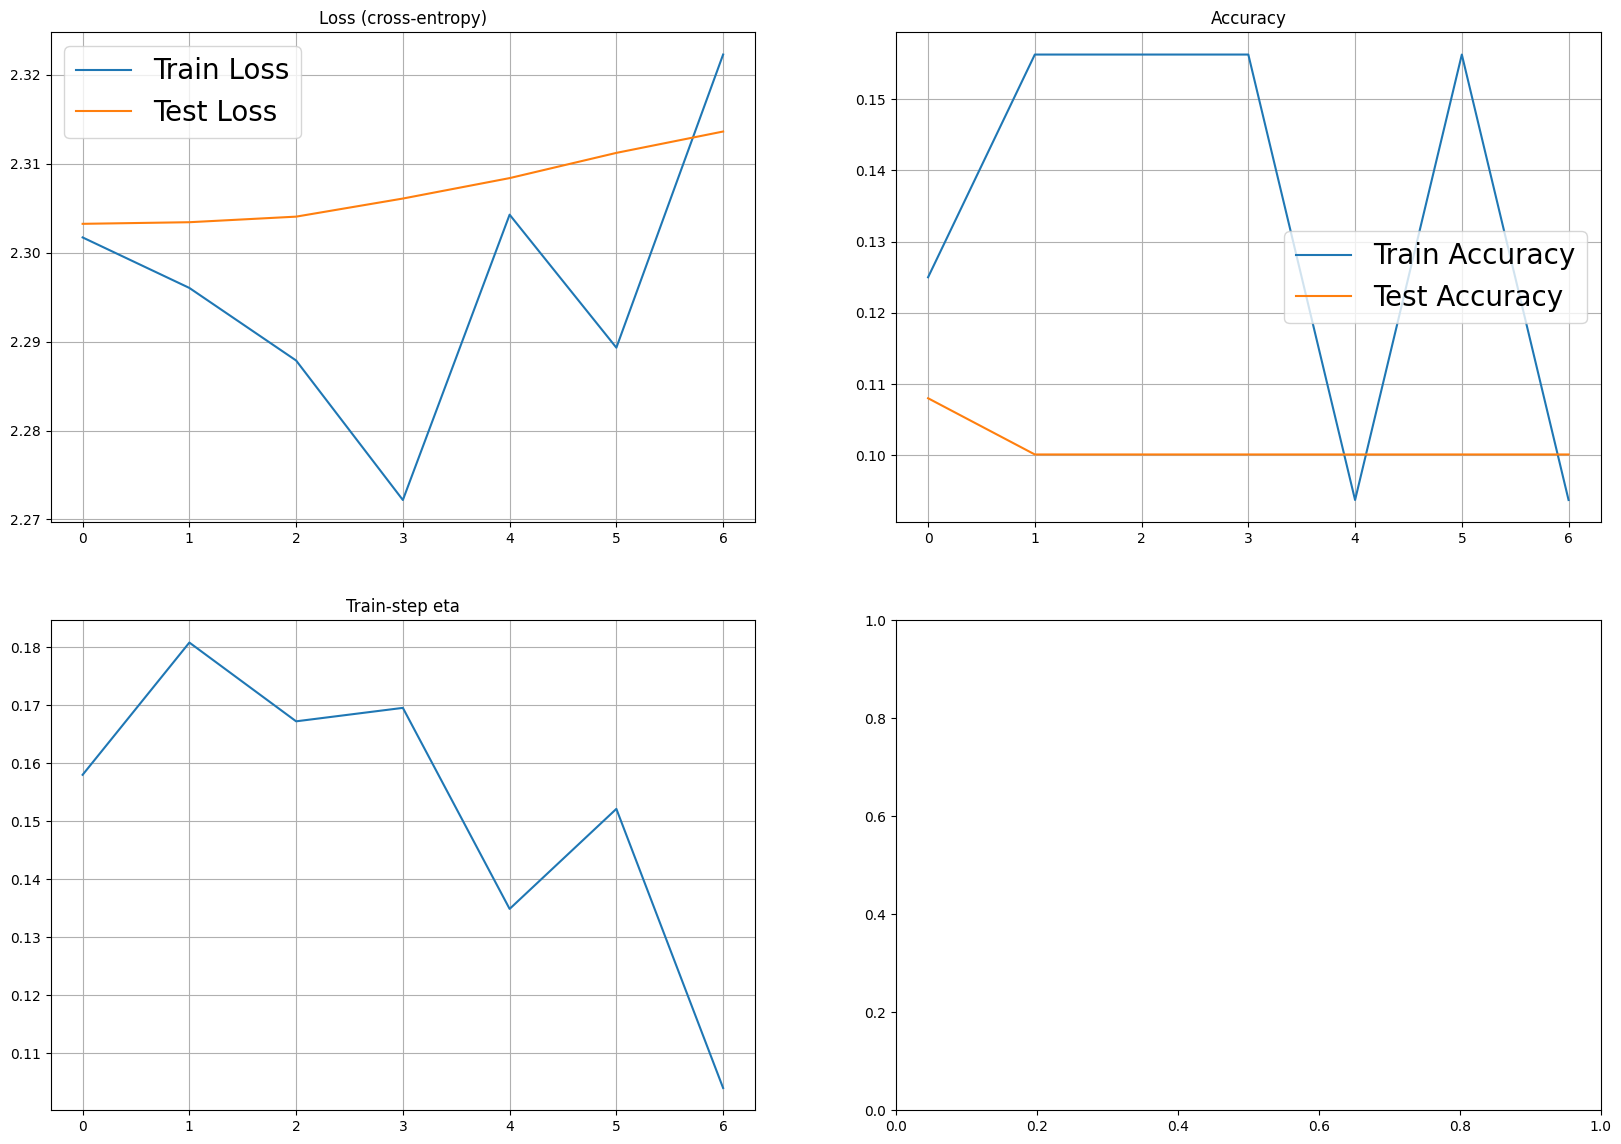

On epoch = 0 test accuracy = 0.10013977635782748


KeyboardInterrupt: 

: 

In [ ]:
#stepCalcZhL = StepCalculatorZhangLambda(meta)
#stepCalcZhS = StepCalculatorZhangSimplified(meta)
#stepCalcSoftmax1 = StepCalculatorEtaSoftmaxArmihoNorm1Base(meta)
Nesterov = True
qu = collections.deque(10*[1.0], 10)
for epoch in range(NUM_EPOCH):
    # training loop
    iter_number = 0
    for train_batch in train_dataloader:
        #testNet.train()
        testNet.do_dropout = True
        iter_number += 1
        momentum = 0.9 #0.75
        use_ones = False
        stepCalcSoftmax2.eta_min = 0.005
        #if np.average(qu) <= 0.025:
        #    use_ones = True
        images, labels = train_batch
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        with torch.no_grad():
            logits = testNet.forward_(images)
            logits_detached = logits.detach().numpy()
            pp = labels_to_softhot(labels, meta.output_dim)
            qq = softmax(np.transpose(logits_detached), axis=(0)) + 1e-8
            qq_active = reduce_to_active(qq, pp)
        qq_active_avg = np.average(qq_active)
        logging.info("##\n --==Initial qq for ones: min={}, max={}, avg={}; momentum={}, Nesterov={}, use_ones={}==--"\
                        .format(np.min(qq_active), np.max(qq_active), qq_active_avg, momentum, Nesterov, use_ones))

        logging.info("##Step with Softmax2 optim")
        eta, logits_latest = stepCalcSoftmax2.step(testNet, labels, images, momentum, Nesterov, use_ones)
        qu.appendleft(eta)

        # calculate current average loss and accuracy
        zz_logits = np.transpose(logits_latest.numpy())
        prediction = logits_latest.argmax(dim=-1)
        loss = loss_crossentropy(zz_logits, labels)
        # save average train loss and accuracy
        HISTORY_PARAMS_N2LAMBDA['train_loss'].append(loss)
        HISTORY_PARAMS_N2LAMBDA['train_accuracy'].append(calculate_accuracy(prediction,labels))
        HISTORY_PARAMS_N2LAMBDA['train_eta'].append(eta)

        #break
        # testing loop
        testNet.do_dropout = False
        test_loss_meter, test_accuracy_meter = AverageMeter(), AverageMeter()
        #testNet.eval()
        for test_batch in test_dataloader:
            images, labels = test_batch
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)
            with torch.no_grad():
                xx = images
                logits = testNet.forward_(xx)

                zz_logits = np.transpose(logits.detach().numpy())
                prediction = logits.argmax(dim=-1).detach()
                loss = loss_crossentropy(zz_logits, labels)
                test_loss_meter.update(loss)
                test_accuracy_meter.update(calculate_accuracy(prediction, labels))

        # save average test accuracy loss and accuracy
        HISTORY_PARAMS_N2LAMBDA['test_loss'].append(test_loss_meter.avg)
        HISTORY_PARAMS_N2LAMBDA['test_accuracy'].append(test_accuracy_meter.avg)
        
        visualise(HISTORY_PARAMS_N2LAMBDA)
        print("On epoch = {} test accuracy = {}".format(epoch, test_accuracy_meter.avg))




In [ ]:
delta_1 = stepCalcSoftmax2.paramProcessor.delta_current
grad_1 = stepCalcSoftmax2.paramProcessor.grad_current
theta_1 = stepCalcSoftmax2.paramProcessor.theta_current
eta1 = eta



In [ ]:
stepCalcSoftmax2.paramProcessor.grad_current['conv1.bias'][0].item()

-0.0009420072310604155

In [ ]:
#step1_conv0_delta_weight = delta_1['conv1.weight'].detach().numpy().copy()
#step1_conv0_delta_bias = delta_1['conv1.bias'].detach().numpy().copy()
step1_conv0_grad_bias = grad_1['conv1.bias'].detach().numpy().copy()
step1_conv0_grad_weight = grad_1['conv1.weight'].detach().numpy().copy()
step1_conv0_theta_bias = theta_1['conv1.bias'].detach().numpy().copy()

In [ ]:
#(init_bias + step1_conv0_delta_bias) - testNet.conv1.bias.detach().numpy()
#((init_weight + step1_conv0_delta_weight) - testNet.conv1.weight.detach().numpy()).sum()
#print(((init_weight + step1_conv0_delta_weight) - testNet.conv1.weight.detach().numpy()).sum())
#grad_1['conv1.bias']
#step1_conv0_delta_weight
init_bias - eta1*step1_conv0_grad_bias - testNet.conv1.bias.detach().numpy()
#(init_weight - eta1*step1_conv0_grad_weight - testNet.conv1.weight.detach().numpy()).sum()

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
      dtype=float32)

In [ ]:
stepCalcSoftmax2.paramProcessor.set_theta(testNet, momentum, eta1, 1.0)

In [ ]:
(init_bias - eta1*step1_conv0_grad_bias) - testNet.conv1.bias.detach().numpy() #

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
      dtype=float32)

In [ ]:
#step1_conv0_theta_bias - init_bias
testNet.conv1.bias[0].item()

-0.011744370684027672

In [ ]:
conv1_grad_weight = stepCalcSoftmax2.conv1_grad_weight.detach().numpy().copy()
conv1_grad_bias = stepCalcSoftmax2.conv1_grad_bias.detach().numpy().copy()
conv1_delta_weight = stepCalcSoftmax2.conv1_delta_weight.detach().numpy().copy()
conv1_delta_bias = stepCalcSoftmax2.conv1_delta_bias.detach().numpy().copy()

In [ ]:
((momentum*conv0_delta_bias + conv1_grad_bias) - conv1_delta_bias)
#((momentum*conv0_delta_weight + conv1_grad_weight) - conv1_delta_weight)


array([-0.04046715, -0.0390957 , -0.06623913, -0.11100551, -0.09053568,
       -0.01083718, -0.00242827, -0.05014316,  0.01137525,  0.00154526,
       -0.00582864,  0.00951518,  0.00410308,  0.0009386 , -0.03459312,
       -0.11446243], dtype=float32)

In [ ]:
((init_bias + (1+momentum)*conv0_delta_bias + conv1_grad_bias) - testNet.conv1.bias.detach().numpy())
#np.abs(((init_weight + (1+momentum)*conv0_delta_weight + conv1_grad_weight) - testNet.conv1.weight.detach().numpy())).sum()


array([0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 7.4505806e-09, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 7.4505806e-09, 1.4901161e-08, 0.0000000e+00,
       7.4505806e-09, 1.8626451e-09, 0.0000000e+00, 0.0000000e+00],
      dtype=float32)

In [ ]:
stepCalcSoftmax2.do_step_grad(testNet, -1.0, update_delta = True)
conv1_delta_weight = stepCalcSoftmax2.conv1_delta_weight.detach().numpy().copy()
conv1_delta_bias = stepCalcSoftmax2.conv1_delta_bias.detach().numpy().copy()

updating deltas


In [ ]:
#((init_bias + (1+momentum)*conv0_delta_bias) - testNet.conv1.bias.detach().numpy())
#((momentum*conv0_delta_bias) - conv1_delta_bias)/conv1_delta_bias
#np.abs(((momentum*conv0_delta_weight) - conv1_delta_weight)).sum()
np.abs(conv1_delta_weight).sum()

0.5945138

In [ ]:
HISTORY_PARAMS_N2LAMBDA = collections.defaultdict(list)
NUM_EPOCH = 5

testNet = CIFAR10ReLU()
testNet.set_slopes(slope_plus, slope_minus)
#testNet.init_weights(cb, cw)
testNet.do_dropout = False
testNet.to(DEVICE)

#stepCalcZhL = StepCalculatorZhangLambda(meta)
#stepCalcZhS = StepCalculatorZhangSimplified(meta)
#stepCalcSoftmax1 = StepCalculatorEtaSoftmaxArmihoNorm1Base(meta)
qu = collections.deque(10*[1.0], 10)
stepCalcSoftmax2 = StepCalculatorEtaSoftmaxArmihoNorm2Base(meta)
for epoch in range(NUM_EPOCH):
    # training loop
    train_loss_meter, train_accuracy_meter, train_eta_meter = AverageMeter(), AverageMeter(), AverageMeter()
    iter_number = 0
    for train_batch in train_dataloader:
        #testNet.train()
        iter_number += 1
        images, labels = train_batch
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        xx = images
        momentum = 0.75
        if np.average(qu) < 0.1:
            momentum = 0.9        

        with torch.no_grad():
            logits = testNet.forward_(xx)
            logits_detached = logits.detach().numpy()
            pp = labels_to_softhot(labels, meta.output_dim)
            qq = softmax(np.transpose(logits_detached), axis=(0)) + 1e-8
            qq_active = reduce_to_active(qq, pp)
        qq_active_avg = np.average(qq_active)
        logging.info("##\n --==Initial qq for ones: min={}, max={}, avg={}==--"\
                        .format(np.min(qq_active), np.max(qq_active), qq_active_avg))
        #if qq_active_avg > 0.3:
        logging.info("##Step with Softmax2 optim")
        #logging.info("##Logits: {}".format(logits_detached))
        eta, logits_latest = stepCalcSoftmax2.step(testNet, logits_detached, labels, xx)
        #else:

        # calculate current average loss and accuracy
        zz_logits = np.transpose(logits_latest.numpy())
        prediction = logits_latest.argmax(dim=-1)
        loss = loss_crossentropy(zz_logits, labels)
        train_loss_meter.update(loss)
        train_accuracy_meter.update(calculate_accuracy(prediction,labels))
        train_eta_meter.update(eta)

    # save average train loss and accuracy
    HISTORY_PARAMS_N2LAMBDA['train_loss'].append(train_loss_meter.avg)
    HISTORY_PARAMS_N2LAMBDA['train_accuracy'].append(train_accuracy_meter.avg)
    HISTORY_PARAMS_N2LAMBDA['train_eta'].append(train_eta_meter.avg)

    # testing loop
    test_loss_meter, test_accuracy_meter = AverageMeter(), AverageMeter()
    #testNet.eval()
    for test_batch in test_dataloader:
        images, labels = test_batch
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        with torch.no_grad():
            xx = images
            logits = testNet.forward_(xx)

            zz_logits = np.transpose(logits.detach().numpy())
            prediction = logits.argmax(dim=-1).detach()
            loss = loss_crossentropy(zz_logits, labels)
            test_loss_meter.update(loss)
            test_accuracy_meter.update(calculate_accuracy(prediction, labels))

    # save average test accuracy loss and accuracy
    HISTORY_PARAMS_N2LAMBDA['test_loss'].append(test_loss_meter.avg)
    HISTORY_PARAMS_N2LAMBDA['test_accuracy'].append(test_accuracy_meter.avg)
    
    visualise(HISTORY_PARAMS_N2LAMBDA)
    print("On epoch = {} test accuracy = {}".format(epoch, test_accuracy_meter.avg))




TypeError: StepCalculatorEtaSoftmaxArmihoNorm2Base.step() missing 1 required positional argument: 'momentum'